# FBA analysis 

In [2]:
import cobra
from scipy.io import loadmat

In [3]:
tumor_path   = "/Users/valentinreateguirangel/Documents/MATLAB/MyProject/COBRA_project/cobratoolbox/tumorModel.mat"
healthy_path = "/Users/valentinreateguirangel/Documents/MATLAB/MyProject/COBRA_project/cobratoolbox/healthyModel.mat"

### Loading Tumor model 

In [5]:
# Load the MATLAB .mat model
from cobra.io import load_matlab_model

tumor_model = load_matlab_model(
    tumor_path,
    variable_name="tumorModel"   
)

### Loading Healthy model 

In [9]:
# Load the MATLAB .mat model
from cobra.io import load_matlab_model

healthy_model = load_matlab_model(
    healthy_path,
    variable_name="healthyModel"   
)

### Cheking for biomass reaction ID

In [11]:
# 1. List every reaction that still has a non-zero objective coefficient
c_rxns = [r for r in tumor_model.reactions if r.objective_coefficient != 0]
print("Objective-flagged reactions:", c_rxns)
# If this prints an empty list, no objective is set.

# 2. Search reaction *names* as well as IDs
hit = [r.id for r in tumor_model.reactions if 'biomass' in r.name.lower()]
print("Reactions whose *name* contains 'biomass':", hit)

Objective-flagged reactions: [<Reaction MAR13082 at 0x168ec9d00>]
Reactions whose *name* contains 'biomass': ['MAR10024', 'MAR10062', 'MAR10063', 'MAR10064', 'MAR10065', 'MAR13082']


### Loading full model to extract biomass_human and push it back to the models 

In [13]:
from cobra.io import read_sbml_model

full_model = read_sbml_model("/Users/valentinreateguirangel/Downloads/Human-GEM-1.19.0/model/Human-GEM.xml")

In [14]:
# List all biomass term contained in GEM model 
biomass_rxns = [rxn for rxn in full_model.reactions 
                if 'biomass' in rxn.id.lower() or 'biomass' in rxn.name.lower()]
for rxn in biomass_rxns:
    print(rxn.id, ":", rxn.name)

MAR04413 : Generic Human Biomass Reaction
MAR09931 : Biomass maintenance reaction without replication precursors
MAR09932 : Biomass maintenance reaction without replication, transcription, and translation precursors
MAR12140 : HMR Biomass Renal Cancer Reaction
MAR10024 : Exchange of biomass
MAR10062 : Protein pool for biomass reaction
MAR10063 : Lipid pool for biomass reaction
MAR10064 : Small metabolite pool for biomass reaction
MAR10065 : Cofactors and vitamins pool for biomass reaction
MAR13082 : Generic human cell biomass reaction


In [15]:
# Biomass reaction = MAR13082
biomass_rxn = full_model.reactions.get_by_id("MAR13082")

In [16]:
# Adding back to tumor and healhty model 
tumor_model.add_reactions([biomass_rxn.copy()])
tumor_model.objective = "MAR13082"

healthy_model.add_reactions([biomass_rxn.copy()])
healthy_model.objective = "MAR13082"

Ignoring reaction 'MAR13082' since it already exists.
Ignoring reaction 'MAR13082' since it already exists.


### FBA

In [19]:
# Activating Nutrients bakc in Python 
nutrient_bounds = {
    "MAR09034": -10,    # Glucose
    "MAR09048": -1000,  # Oxygen
    "MAR09041": -1,     # Arginine
    "MAR09047": -1,     # Lysine
    "MAR09049": -1,     # Methionine
    "MAR09043": -1,     # Phenylalanine
    "MAR09045": -1,     # Tryptophan
    "MAR09050": -1,     # Histidine
    "MAR09042": -1,     # Isoleucine
    "MAR09044": -1,     # Leucine
    "MAR09040": -1,     # Threonine
    "MAR09046": -1      # Valine
}

for rxn_id, lb in nutrient_bounds.items():
    try:
        rxn = tumor_model.reactions.get_by_id(rxn_id)
        rxn.lower_bound = lb
        rxn.upper_bound = 1000
    except KeyError:
        print(f"  {rxn_id} not found in tumor model — skipping.")

for rxn_id, lb in nutrient_bounds.items():
    try:
        rxn = healthy_model.reactions.get_by_id(rxn_id)
        rxn.lower_bound = lb
        rxn.upper_bound = 1000
    except KeyError:
        print(f"  {rxn_id} not found in healthy model — skipping.")

In [20]:
# Tumor
tumor_solution = tumor_model.optimize()
print("Biomass flux =", tumor_solution.objective_value)

Biomass flux = 124.86814837744573


In [21]:
# Healhty
healthy_solution = healthy_model.optimize()
print("Biomass flux =", healthy_solution.objective_value)

Biomass flux = 124.86814837744568


## Flux Data Exploration 

In [53]:
import pandas as pd 

# Comparing fluxes
flux_df = (
    pd.DataFrame({"tumor": tumor_solution.fluxes,
                  "healthy": healthy_solution.fluxes})
      .dropna()
)
flux_df["Δ"]  = flux_df["tumor"] - flux_df["healthy"]
flux_df["|Δ|"]= flux_df["Δ"].abs()

In [61]:
# Mapping of reaction ID to reaction name 
id_to_name = {rxn.id: rxn.name for rxn in tumor_model.reactions}

# Add a new column with reaction names
flux_df["reaction_name"] = flux_df.index.map(id_to_name)

# Reorder columns to make it readable
flux_df = flux_df[["reaction_name", "tumor", "healthy", "Δ", "|Δ|"]]

# View top flux changes with names
flux_df.sort_values("|Δ|", ascending=False).head()

,reaction_name,tumor,healthy,Δ,|Δ|
MAR09439,Exchange of uridine,3.789879,-1000.0,1003.789879,1003.789879
MAR04579,uridine:phosphate alpha-D-ribosyltransferase,-3.789879,1000.0,-1003.789879,1003.789879
MAR08486,adenosine:phosphate alpha-D-ribosyltransferase,1000.000000,0.0,1000.000000,1000.000000
MAR04199,,0.000000,-1000.0,1000.000000,1000.000000
MAR05035,,0.000000,-1000.0,1000.000000,1000.000000


### Flux Reactions, Tumor vs Healthy

In [112]:
# Get the flux values from the solution
flux_tumor_series = tumor_solution.fluxes
flux_healthy_series = healthy_solution.fluxes

# Check absolute values against a small threshold (e.g. 1e-6) as common tolerance in metabolic modeling 
is_zero_t = flux_tumor_series.abs() < 1e-6
is_zero_h = flux_healthy_series.abs() < 1e-6

In [114]:
# Count how many are zero or nearly for Tumor flux
zero_count = is_zero_t.sum()
nonzero_count = (~is_zero_t).sum()
total_count = len(flux_tumor_series)

print(f"Total reactions in Tumor flux: {total_count}")
print(f"Zero-flux reactions Tumor flux: {zero_count}")
print(f"Active (non-zero) reactions Tumor flux: {nonzero_count}")

Total reactions in Tumor flux: 11583
Zero-flux reactions Tumor flux: 10771
Active (non-zero) reactions Tumor flux: 812


In [117]:
# Count how many are zero or nearly for Healthy flux
zero_count = is_zero_h.sum()
nonzero_count = (~is_zero_h).sum()
total_count = len(flux_healthy_series)

print(f"Total reactions in Healthy flux: {total_count}")
print(f"Zero-flux reactions Healthy flux: {zero_count}")
print(f"Active (non-zero) reactions Healthy flux: {nonzero_count}")

Total reactions in Healthy flux: 12971
Zero-flux reactions Healthy flux: 11908
Active (non-zero) reactions Healthy flux: 1063


### FBA visualization 

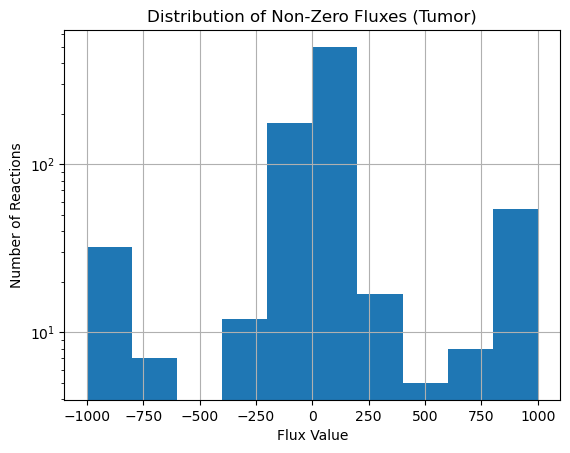

In [131]:
flux_series[~is_zero_t].hist(bins=10)
plt.title("Distribution of Non-Zero Fluxes (Tumor)")
plt.xlabel("Flux Value")
plt.ylabel("Number of Reactions")
plt.yscale('log') 
plt.show()

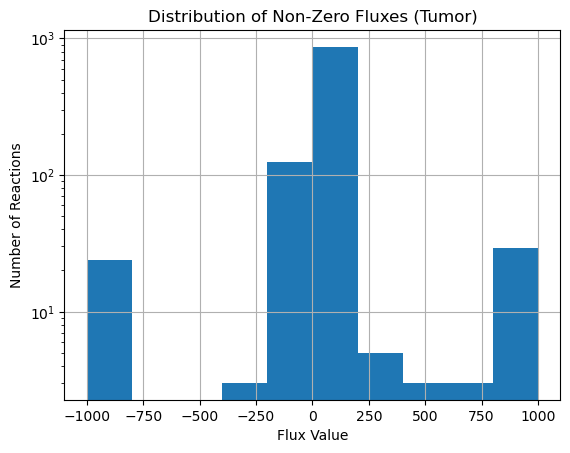

In [139]:
flux_series[~is_zero_h].hist(bins=10)
plt.title("Distribution of Non-Zero Fluxes (Tumor)")
plt.xlabel("Flux Value")
plt.ylabel("Number of Reactions")
plt.yscale('log') 
plt.show()

## Creating a small subnetwork for each model 

### Picking a Reaction from the list 

In [142]:
# Tumor model 
t_model = tumor_model

# Search for reactions that associate glucose 
glucose_reactions = [
    r for r in t_model.reactions
    if "glucose" in r.name.lower()
]

for rxn in glucose_reactions:
    print (f"{rxn.id: <10} → {rxn.name}")

MAR04381   → D-glucose-6-phosphate aldose-ketose-isomerase
MAR04394   → ATP:D-glucose 6-phosphotransferase
MAR04396   → alpha-D-glucose 1,6-phosphomutase
MAR04521   → D-Glucose-6-phosphate phosphohydrolase
MAR07747   → ADP:D-glucose 6-phosphotransferase
MAR04122   → UDP-glucose:NAD+ 6-oxidoreductase
MAR05395   → UDP-alpha-D-glucose:glycogenin alpha-D-glucosyltransferase
MAR08585   → 3-phospho-D-glyceroyl-phosphate:alpha-D-glucose-1-phosphate 6-phosphotransferase
MAR03944   → UTP:alpha-D-glucose-1-phosphate uridylyltransferase
MAR04128   → UDP-glucose 4-epimerase
MAR04131   → UDP-glucose:alpha-D-galactose-1-phosphate uridylyltransferase
MAR04132   → UDP-glucose:alpha-D-galactose-1-phosphate uridylyltransferase
MAR07674   → UDP-alpha-D-galactose:D-glucose 4-beta-D-galactosyltransferase
MAR04304   → D-glucose-6-phosphate:NADP+ 1-oxidoreductase
MAR08653   → D-glucose-6-phosphate:NAD+ 1-oxidoreductase
MAR04486   → ITP:D-glucose 6-phosphotransferase
MAR04487   → dATP:D-glucose 6-phosphotrans

In [150]:
#Healhty model 
h_model = healthy_model

# Search for reactions that associate glucose 
glucose_reactions = [
    r for r in h_model.reactions
    if "glucose" in r.name.lower()
]

for rxn in glucose_reactions:
    print (f"{rxn.id: <10} → {rxn.name}")

MAR04381   → D-glucose-6-phosphate aldose-ketose-isomerase
MAR04394   → ATP:D-glucose 6-phosphotransferase
MAR04396   → alpha-D-glucose 1,6-phosphomutase
MAR04521   → D-Glucose-6-phosphate phosphohydrolase
MAR07745   → D-glucose 1-epimerase
MAR07747   → ADP:D-glucose 6-phosphotransferase
MAR04122   → UDP-glucose:NAD+ 6-oxidoreductase
MAR05395   → UDP-alpha-D-glucose:glycogenin alpha-D-glucosyltransferase
MAR08585   → 3-phospho-D-glyceroyl-phosphate:alpha-D-glucose-1-phosphate 6-phosphotransferase
MAR03944   → UTP:alpha-D-glucose-1-phosphate uridylyltransferase
MAR04128   → UDP-glucose 4-epimerase
MAR04131   → UDP-glucose:alpha-D-galactose-1-phosphate uridylyltransferase
MAR04132   → UDP-glucose:alpha-D-galactose-1-phosphate uridylyltransferase
MAR07674   → UDP-alpha-D-galactose:D-glucose 4-beta-D-galactosyltransferase
MAR04304   → D-glucose-6-phosphate:NADP+ 1-oxidoreductase
MAR08653   → D-glucose-6-phosphate:NAD+ 1-oxidoreductase
MAR04486   → ITP:D-glucose 6-phosphotransferase
MAR0448

In [159]:
target_reaction = "MAR04394"

### Gathering Metabolites 

In [162]:
reaction = tumor_model.reactions.get_by_id(target_reaction)

In [172]:
# Split into reactants and products 
reactants =[m for m, coeff in reaction.metabolites.items() if coeff < 0] 
products  =[m for m, coeff in reaction.metabolites.items() if coeff > 0]

In [176]:
# Print reactants
print("Reactants:")
for m in reactants:
    print(f"  {m.id: <20} → {m.name}")

# Print products
print("\nProducts:")
for m in products:
    print(f"  {m.id: <20} → {m.name}")

Reactants:
  MAM01371c            → ATP
  MAM01965c            → glucose

Products:
  MAM01285c            → ADP
  MAM01968c            → glucose-6-phosphate
  MAM02039c            → H+


In [178]:
tumor_solution.fluxes["MAR04394"]

0.0

In [180]:
healthy_solution.fluxes["MAR04394"]

0.38787052986230497

### Small network 

#### Healthy

In [185]:
import networkx as nx 
import matplotlib.pyplot as plt 

# graph object
G = nx.DiGraph()

# adding metabolite nodes with readable names 
metabolites = {
    "MAM01965c": "glucose",
    "MAM01371c": "ATP",
    "MAM01968c": "glucose-6-phosphate",
    "MAM01285c": "ADP"
}

In [189]:
# Adding metabolites 
for met_id, met_name in metabolites.items():
    G.add_node(met_id, label=met_name)

In [214]:
# Edges from reactants 
flux_value = healthy_solution.fluxes[target_reaction]

In [216]:
# Defining conections 
edges = [
    ("MAM01965c", "MAM01968c"),  # glucose → glucose-6-phosphate
    ("MAM01371c", "MAM01285c")   # ATP → ADP
]

In [218]:
# add each edge with flux value 
for src, tgt in edges:
    G.add_edge(src, tgt, reaction= target_reaction, flux=flux_value)

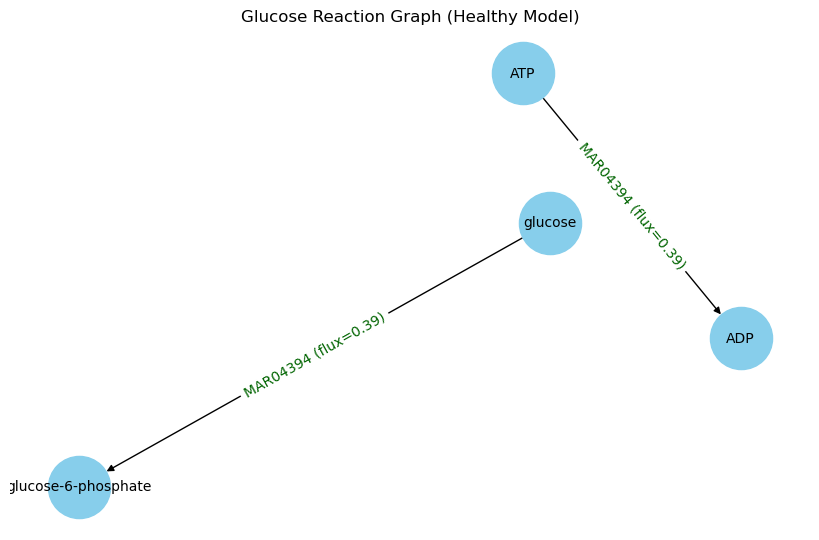

In [222]:
# Drqwing graph
pos = nx.spring_layout(G, seed=1)  # auto layout
labels = nx.get_node_attributes(G, 'label')
edge_labels = {
    (u, v): f"{G[u][v]['reaction']} (flux={G[u][v]['flux']:.2f})"
    for u, v in G.edges()
}

plt.figure(figsize=(8, 5))
nx.draw(G, pos, labels=labels, with_labels=True, node_color="skyblue", node_size=2000, font_size=10, arrows=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="darkgreen")
plt.title("Glucose Reaction Graph (Healthy Model)")
plt.axis("off")
plt.show()

#### Tumor

In [231]:
# graph object
G = nx.DiGraph()

# adding metabolite nodes with readable names 
metabolites = {
    "MAM01965c": "glucose",
    "MAM01371c": "ATP",
    "MAM01968c": "glucose-6-phosphate",
    "MAM01285c": "ADP"
}

In [233]:
# Adding metabolites 
for met_id, met_name in metabolites.items():
    G.add_node(met_id, label=met_name)

In [235]:
# Edges from reactants 
flux_value = tumor_solution.fluxes[target_reaction]

In [237]:
# Defining conections 
edges = [
    ("MAM01965c", "MAM01968c"),  # glucose → glucose-6-phosphate
    ("MAM01371c", "MAM01285c")   # ATP → ADP
]

In [239]:
# add each edge with flux value 
for src, tgt in edges:
    G.add_edge(src, tgt, reaction= target_reaction, flux=flux_value)

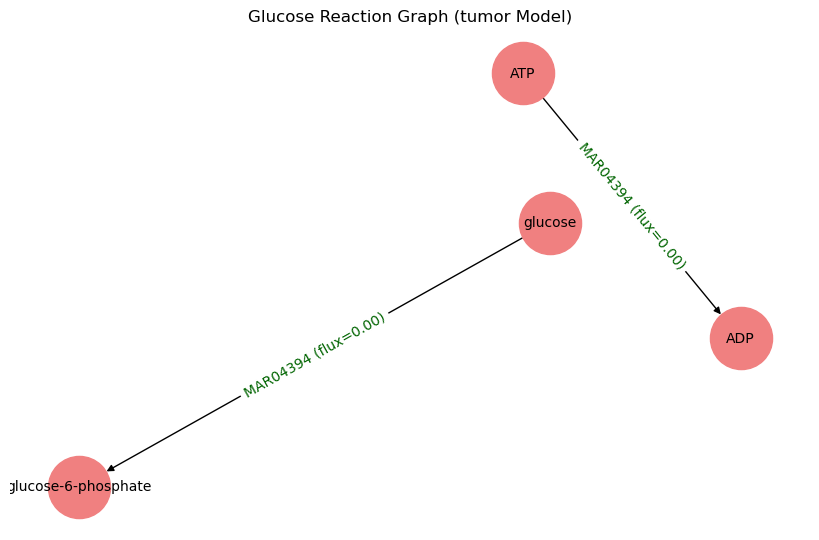

In [243]:
# Drqwing graph
pos = nx.spring_layout(G, seed=1)  # auto layout
labels = nx.get_node_attributes(G, 'label')
edge_labels = {
    (u, v): f"{G[u][v]['reaction']} (flux={G[u][v]['flux']:.2f})"
    for u, v in G.edges()
}

plt.figure(figsize=(8, 5))
nx.draw(G, pos, labels=labels, with_labels=True, node_color="lightcoral", node_size=2000, font_size=10, arrows=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="darkgreen")
plt.title("Glucose Reaction Graph (tumor Model)")
plt.axis("off")
plt.show()